# Trabajo 2 — Lectura de datos y análisis descriptivo (Graduate Admissions Dataset)

**Variable respuesta**: Chance of Admit transformada a clasificación binaria:

* `admit = yes` si `Chance of Admit >= 0.6`
* `admit = no` en caso contrario

Objetivo: leer el dataset, construir la variable respuesta binaria y realizar un análisis descriptivo completo que soporte la modelización con árboles de clasificación: calidad de datos (missing), definición de conjuntos (modelización/validación/test), análisis de distribuciones, correlaciones y visualizaciones.

Dataset: Graduate Admissions (Kaggle) — archivo: `Admission_Predict.csv`.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
DATA_PATH = "./data/Admission_Predict.csv"

# Carpeta para figuras del informe
FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

## Cargar datos

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.tail())

Shape: (400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67
399,400,333,117,4,5.0,4.0,9.66,1,0.95


## Limpieza mínima + chequeos rápidos

In [3]:
# Normaliza nombres de columnas (por si traen espacios raros)
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Algunos datasets traen "Serial No." como identificador
id_like_cols = [
    c
    for c in df.columns
    if "Serial" in c or c == "No" or c.lower().startswith("serial")
]
print("Posibles columnas ID:", id_like_cols)

display(df.info())
display(df.describe(include="all"))

Posibles columnas ID: ['Serial_No.']
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial_No.         400 non-null    int64  
 1   GRE_Score          400 non-null    int64  
 2   TOEFL_Score        400 non-null    int64  
 3   University_Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance_of_Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


None

,Serial_No.,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


## Variable objetivo binaria (umbral 0.6)

In [4]:
# Busca columna de probabilidad (puede venir con nombre ligeramente distinto)
possible_targets = [c for c in df.columns if "Chance" in c or "Admit" in c]
print("Candidatas a target:", possible_targets)

# Ajusta aquí si tu columna se llama distinto
TARGET_PROB_COL = None
for c in df.columns:
    if c.lower().replace("_","") in ["chanceofadmit", "chanceofadmit_", "chanceofadmit(%)", "chanceofadmit1"]:
        TARGET_PROB_COL = c
        break

# Fallback: si no coincide, usa la más probable por nombre
if TARGET_PROB_COL is None:
    # Elegimos la que contenga "Chance_of_Admit" o similar
    for c in df.columns:
        if "Chance_of_Admit" in c or ("chance" in c.lower() and "admit" in c.lower()):
            TARGET_PROB_COL = c
            break

if TARGET_PROB_COL is None:
    raise ValueError("No encontré la columna 'Chance of Admit'. Revisa el nombre en df.columns.")

print("Columna target prob:", TARGET_PROB_COL)

# Crea la etiqueta binaria: yes si >= 0.6
df["admit_label"] = np.where(df[TARGET_PROB_COL] >= 0.6, "yes", "no")
df["admit"] = (df[TARGET_PROB_COL] >= 0.6).astype(int)  # 1=yes, 0=no

display(df[[TARGET_PROB_COL, "admit_label", "admit"]].head(10))
print(df["admit_label"].value_counts())
print(df["admit_label"].value_counts(normalize=True) * 100)

Candidatas a target: ['Chance_of_Admit']
Columna target prob: Chance_of_Admit


,Chance_of_Admit,admit_label,admit
0,0.92,yes,1
1,0.76,yes,1
2,0.72,yes,1
3,0.80,yes,1
4,0.65,yes,1
5,0.90,yes,1
6,0.75,yes,1
7,0.68,yes,1
8,0.50,no,0
9,0.45,no,0


admit_label
yes    327
no      73
Name: count, dtype: int64
admit_label
yes    81.75
no     18.25
Name: proportion, dtype: float64


## EDA rápido (balance de clases, missing, correlaciones)

admit_label
yes    327
no      73
Name: count, dtype: int64

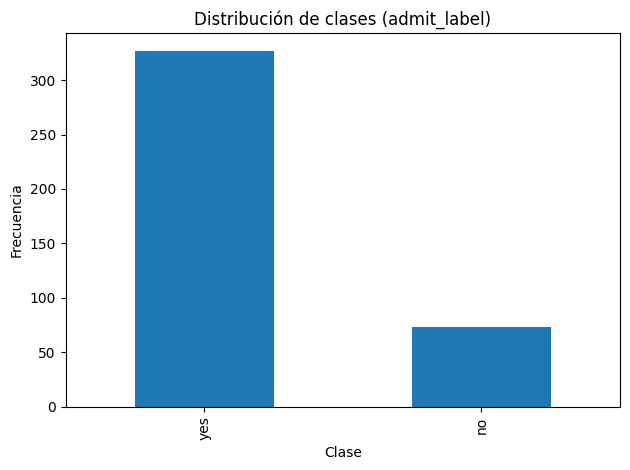

,missing_count


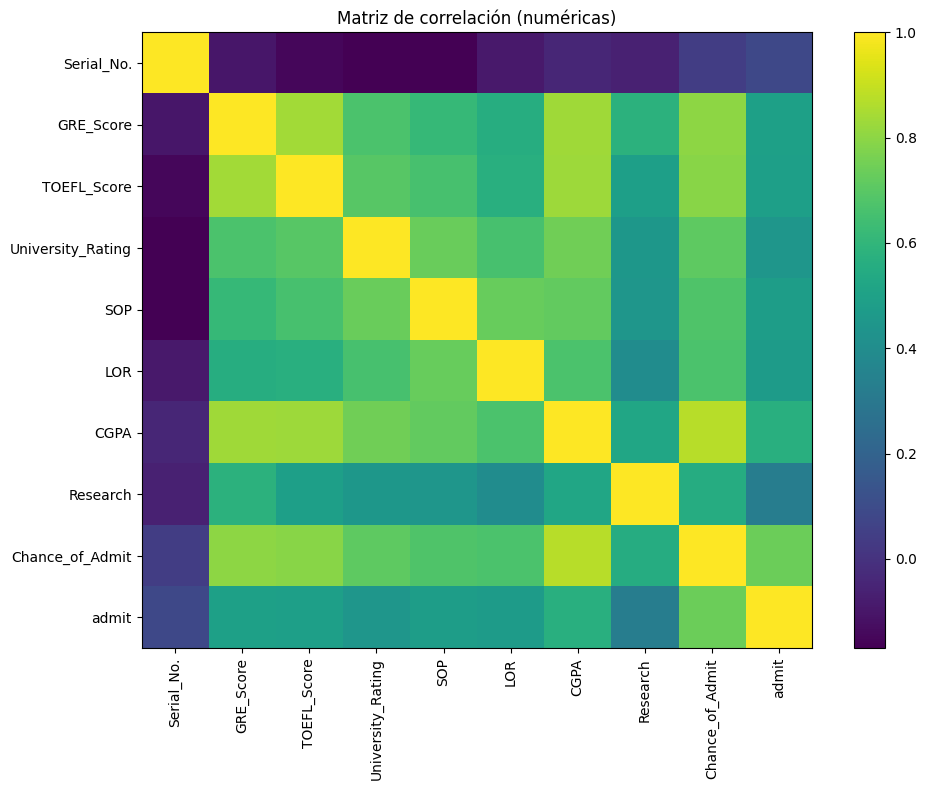

In [5]:
# Balance de clases
counts = df["admit_label"].value_counts()
display(counts)

plt.figure()
counts.plot(kind="bar")
plt.title("Distribución de clases (admit_label)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=300)
plt.show()

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

# Correlación (solo numéricas)
num_df = df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Matriz de correlación (numéricas)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "correlation_matrix.png"), dpi=300)
plt.show()

## Definir X / y (features) + quitar columnas no predictivas

In [6]:
# Columnas a excluir: la probabilidad original y las etiquetas creadas
exclude_cols = {TARGET_PROB_COL, "admit_label", "admit"}

# Elimina IDs si existen
for c in df.columns:
    if "serial" in c.lower():
        exclude_cols.add(c)

X = df.drop(columns=list(exclude_cols))
y = df["admit"]

print("Features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

display(X.head())

Features: ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']
X shape: (400, 7) | y shape: (400,)


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


## train/test split (estratificado)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Balance train:", np.bincount(y_train) if set(np.unique(y_train)) <= {0,1} else pd.Series(y_train).value_counts())
print("Balance test:", np.bincount(y_test) if set(np.unique(y_test)) <= {0,1} else pd.Series(y_test).value_counts())

Train: (320, 7) Test: (80, 7)
Balance train: [ 58 262]
Balance test: [15 65]


## Pipeline + GridSearchCV (Árbol de decisión)

In [8]:
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "clf__criterion": ["gini", "entropy"],  # suficiente para este trabajo
    "clf__max_depth": [None, 2, 3, 4, 5, 6, 8, 10],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",          # buen balance si hay desbalance de clases
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)

search.fit(X_train, y_train)

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor F1 (CV):", round(search.best_score_, 4))
best_model = search.best_estimator_

Mejores hiperparámetros: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
Mejor F1 (CV): 0.9372


## Evaluación en test (métricas + matriz de confusión)

=== Métricas (TEST) ===
Accuracy : 0.925
Precision: 0.9275
Recall   : 0.9846
F1       : 0.9552

Reporte:
               precision    recall  f1-score   support

          no       0.91      0.67      0.77        15
         yes       0.93      0.98      0.96        65

    accuracy                           0.93        80
   macro avg       0.92      0.83      0.86        80
weighted avg       0.92      0.93      0.92        80



<Figure size 640x480 with 0 Axes>

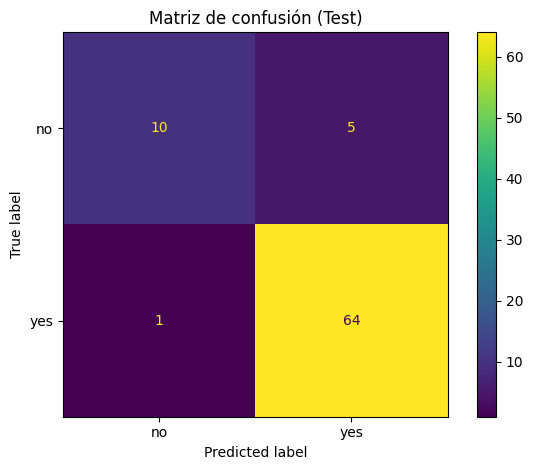

In [9]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=== Métricas (TEST) ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1       :", round(f1, 4))
print("\nReporte:\n", classification_report(y_test, y_pred, target_names=["no", "yes"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])

plt.figure()
disp.plot(values_format="d")
plt.title("Matriz de confusión (Test)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

## Importancia de variables

,importance
CGPA,0.741444
SOP,0.114532
GRE_Score,0.111450
LOR,0.019950
TOEFL_Score,0.012623
Research,0.000000
University_Rating,0.000000


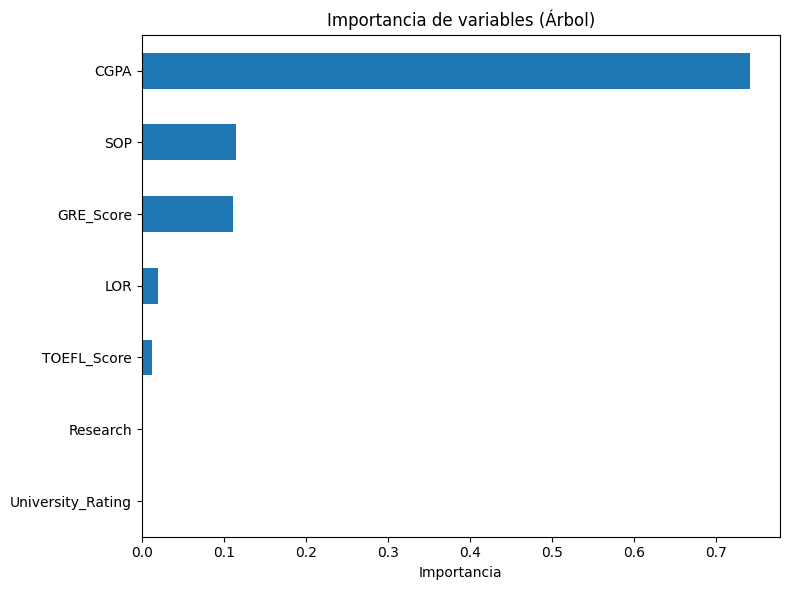

In [10]:
# Extrae el árbol entrenado desde el pipeline
tree_clf = best_model.named_steps["clf"]
feature_names = list(X.columns)

importances = pd.Series(tree_clf.feature_importances_, index=feature_names).sort_values(ascending=True)
display(importances.to_frame("importance").sort_values("importance", ascending=False).head(10))

plt.figure(figsize=(8, 6))
importances.tail(min(12, len(importances))).plot(kind="barh")
plt.title("Importancia de variables (Árbol)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_importance.png"), dpi=300)
plt.show()

## Visualizar el árbol

max_depth del mejor árbol: 3


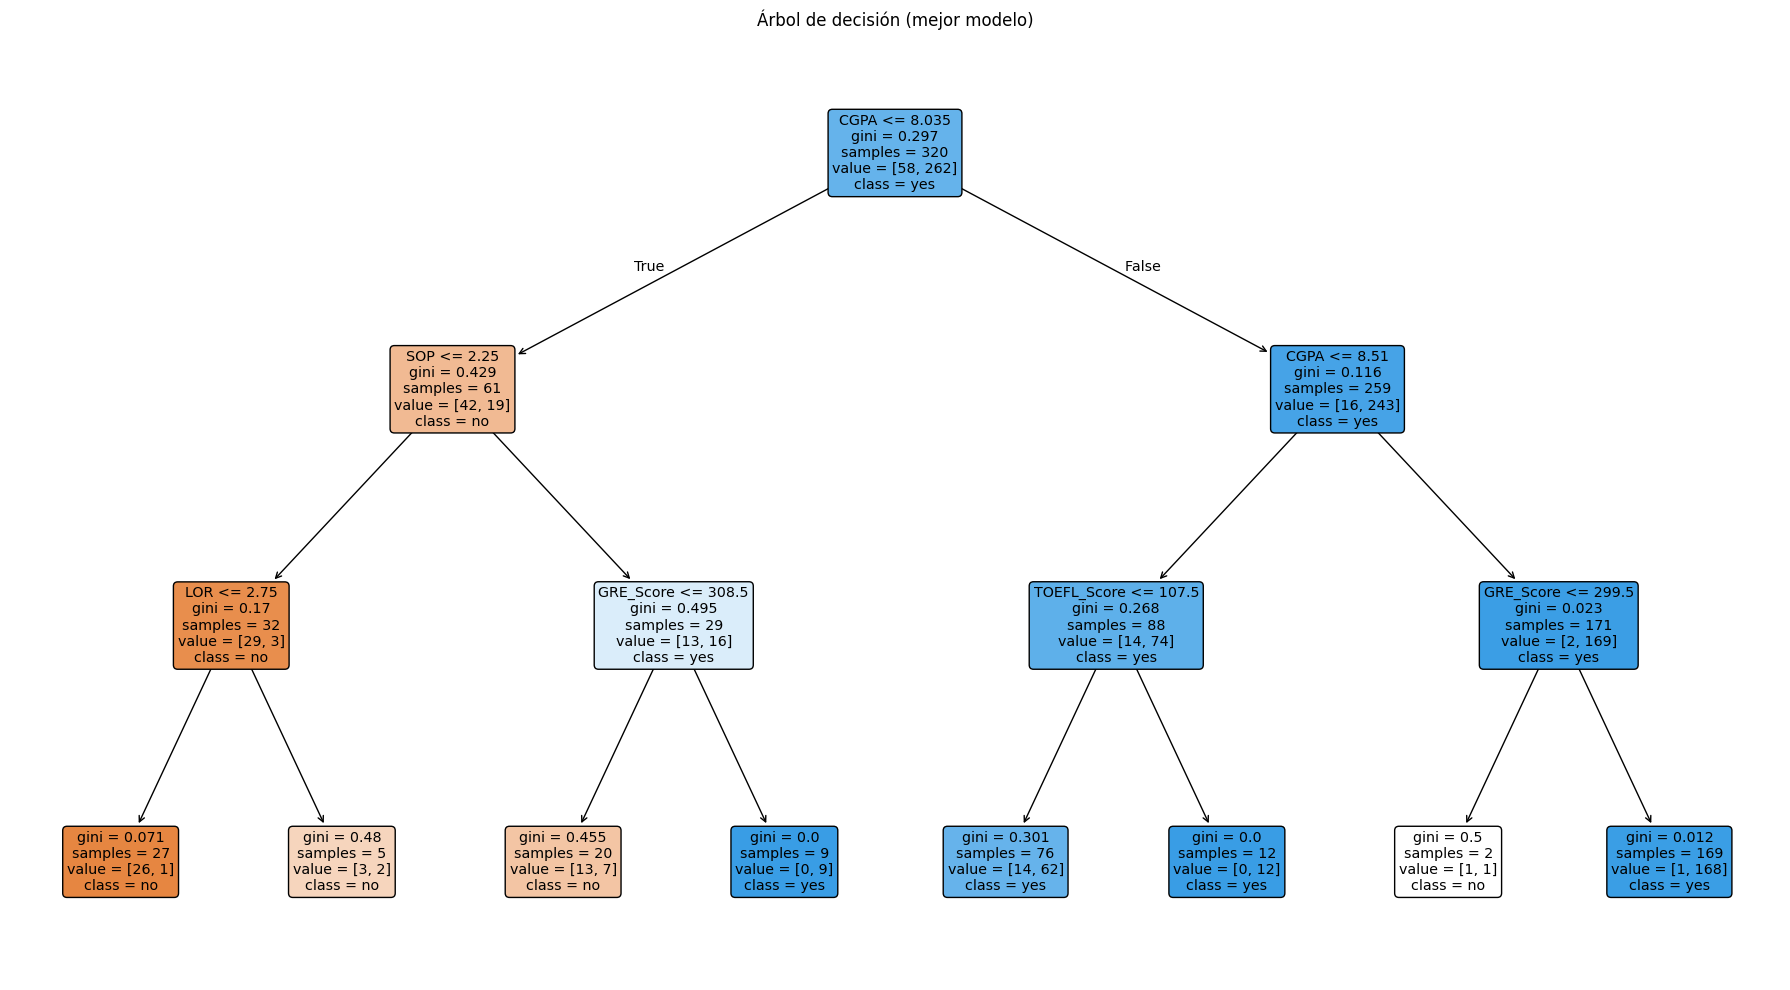

In [11]:
max_depth_to_plot = tree_clf.get_params().get("max_depth", None)
print("max_depth del mejor árbol:", max_depth_to_plot)

plt.figure(figsize=(18, 10))
plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    proportion=False
)
plt.title("Árbol de decisión (mejor modelo)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "decision_tree.png"), dpi=300)
plt.show()

## Ejemplo 1: 3 predicciones tomando 3 filas del test

In [12]:
# 3 ejemplos (tomando 3 casos del conjunto test)
ejemplos = X_test.sample(3, random_state=42)

# Predicción de clase (0/1)
pred_class = best_model.predict(ejemplos)

# Probabilidades (columna 1 = prob de clase "yes" (1))
pred_proba = best_model.predict_proba(ejemplos)[:, 1]

# Valor real
real = y_test.loc[ejemplos.index].values

# Armar tabla resumen
resumen = ejemplos.copy()
resumen["real_admit"] = real
resumen["pred_admit"] = pred_class
resumen["prob_yes"] = np.round(pred_proba, 4)

# Etiquetas bonitas
resumen["real_label"] = np.where(resumen["real_admit"] == 1, "yes", "no")
resumen["pred_label"] = np.where(resumen["pred_admit"] == 1, "yes", "no")

display(resumen[["real_label", "pred_label", "prob_yes"] + list(ejemplos.columns)])

,real_label,pred_label,prob_yes,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
261,yes,yes,0.8158,312,104,3,3.5,4.0,8.09,0
251,yes,yes,0.9941,316,99,2,2.5,3.0,9.00,0
181,yes,yes,0.8158,305,107,2,2.5,2.5,8.42,0


## Ejemplo 2: 3 predicciones escogiendo casos “interesantes”

Este bloque busca: un verdadero positivo, un verdadero negativo y un error (si existe), para que tengas ejemplos más “presentables”.

In [13]:
# Predicciones de TODO el test
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_eval = pd.DataFrame({
    "real": y_test.values,
    "pred": y_test_pred,
    "prob_yes": y_test_proba
}, index=X_test.index)

# Candidatos: TP, TN, y un error (FP o FN)
tp = test_eval[(test_eval.real == 1) & (test_eval.pred == 1)].head(1)
tn = test_eval[(test_eval.real == 0) & (test_eval.pred == 0)].head(1)
err = test_eval[(test_eval.real != test_eval.pred)].head(1)  # puede estar vacío si clasifica perfecto

indices = list(tp.index) + list(tn.index) + list(err.index)
ejemplos2 = X_test.loc[indices]

pred_class2 = best_model.predict(ejemplos2)
pred_proba2 = best_model.predict_proba(ejemplos2)[:, 1]
real2 = y_test.loc[indices].values

resumen2 = ejemplos2.copy()
resumen2["real_admit"] = real2
resumen2["pred_admit"] = pred_class2
resumen2["prob_yes"] = np.round(pred_proba2, 4)
resumen2["real_label"] = np.where(resumen2["real_admit"] == 1, "yes", "no")
resumen2["pred_label"] = np.where(resumen2["pred_admit"] == 1, "yes", "no")

display(resumen2[["real_label", "pred_label", "prob_yes"] + list(ejemplos2.columns)])

,real_label,pred_label,prob_yes,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
251,yes,yes,0.9941,316,99,2,2.5,3.0,9.00,0
316,no,no,0.0370,298,101,2,1.5,2.0,7.86,0
9,no,yes,0.9941,323,108,3,3.5,3.0,8.60,0


## Ejemplo 3: predicción manual (tú escribes el perfil)

Útil si quieres un “caso inventado” para el informe. Solo debes poner los valores con los mismos nombres de columnas que X.columns.

In [14]:
# Crea un caso manual (rellena con valores coherentes para tu dataset)
# OJO: las claves deben coincidir con X.columns
caso_manual = {
    col: float(X[col].median())  # base: medianas para completar
    for col in X.columns
}

# Ajusta algunas variables (ejemplo; cambia según tus columnas reales)
# caso_manual["GRE_Score"] = 320
# caso_manual["TOEFL_Score"] = 110
# caso_manual["CGPA"] = 9.2
# caso_manual["Research"] = 1

df_manual = pd.DataFrame([caso_manual])

pred_m = best_model.predict(df_manual)[0]
proba_m = best_model.predict_proba(df_manual)[0, 1]

print("Predicción:", "yes" if pred_m == 1 else "no")
print("Probabilidad (yes):", round(proba_m, 4))
display(df_manual)

Predicción: yes
Probabilidad (yes): 0.9941


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
0,317.0,107.0,3.0,3.5,3.5,8.61,1.0
